In [22]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
X, y = make_classification(n_samples=5000, n_features=20, random_state=42)

In [6]:
X.shape, y.shape

((5000, 20), (5000,))

In [16]:
model=Sequential()

In [17]:
model.add(Dense(32, activation='relu', input_dim=20))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [18]:
model.compile(loss="binary_crossentropy", optimizer='adam', metrics=['accuracy'])

In [19]:
history=model.fit(X, y, epochs=1000, validation_split=0.2)

Epoch 1/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7925 - loss: 0.5031 - val_accuracy: 0.8380 - val_loss: 0.3734
Epoch 2/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8587 - loss: 0.3340 - val_accuracy: 0.8490 - val_loss: 0.3469
Epoch 3/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8675 - loss: 0.3164 - val_accuracy: 0.8480 - val_loss: 0.3468
Epoch 4/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8710 - loss: 0.3118 - val_accuracy: 0.8500 - val_loss: 0.3451
Epoch 5/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8763 - loss: 0.3064 - val_accuracy: 0.8510 - val_loss: 0.3446
Epoch 6/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8770 - loss: 0.3021 - val_accuracy: 0.8570 - val_loss: 0.3454
Epoch 7/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8785 - loss: 0.2987 - val_accuracy: 0.8570 - val_loss: 0.3438
Epoch 8/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8802 - loss: 0.2959 - 

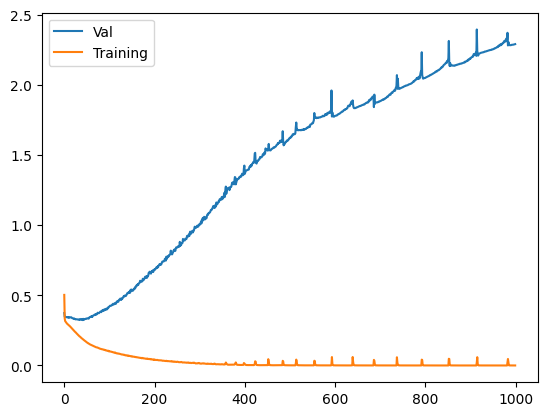

In [30]:
plt.plot(history.history['val_loss'], label='Val')
plt.plot(history.history['loss'], label="Training")
plt.legend()
plt.show()
# clear case of overfitting

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

In [34]:
callback=EarlyStopping(
    monitor='val_loss',
    min_delta=0.00001,
    patience=20,
    verbose=20,
    mode='min'
)

In [35]:
model=Sequential()

In [36]:
model.add(Dense(32, activation='relu', input_dim=20))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [39]:
model.compile(loss="binary_crossentropy", optimizer='adam', metrics=['accuracy'], callbacks=callback)

In [40]:
history=model.fit(X, y, epochs=1000, validation_split=0.2, callbacks=callback)

Epoch 1/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7122 - loss: 0.5493 - val_accuracy: 0.8070 - val_loss: 0.4171
Epoch 2/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8572 - loss: 0.3496 - val_accuracy: 0.8360 - val_loss: 0.3616
Epoch 3/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8708 - loss: 0.3192 - val_accuracy: 0.8430 - val_loss: 0.3589
Epoch 4/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8725 - loss: 0.3130 - val_accuracy: 0.8440 - val_loss: 0.3557
Epoch 5/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8763 - loss: 0.3086 - val_accuracy: 0.8470 - val_loss: 0.3571
Epoch 6/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8785 - loss: 0.3041 - val_accuracy: 0.8440 - val_loss: 0.3572
Epoch 7/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8783 - loss: 0.3007 - val_accuracy: 0.8480 - val_loss: 0.3581
Epoch 8/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8817 - loss: 0.2972 - 

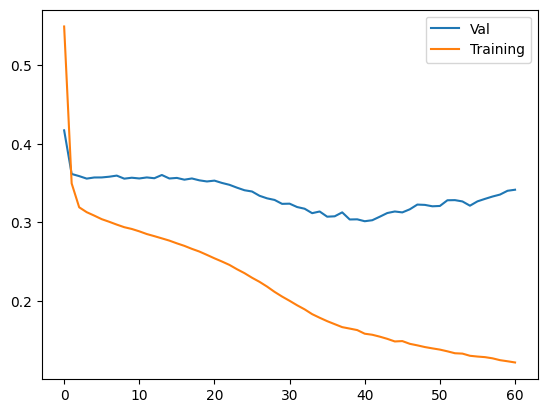

In [41]:
plt.plot(history.history['val_loss'], label='Val')
plt.plot(history.history['loss'], label="Training")
plt.legend()
plt.show()